# RQ2: forecasting transaction value

A lag-based regression on the monthly panel, tested on the last 12 months. Again just numpy so it runs anywhere.

## Setup (local or Google Colab)

On Colab this pulls the project data and code from GitHub. Locally it uses the repo folder you already have.

In [1]:
# Works whether you run this locally or on Google Colab.
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB and not os.path.isdir('data'):
    import subprocess
    subprocess.run(['git','clone','-q','https://github.com/bcudjoe/mobile-money-ghana-forecasting.git'])
    os.chdir('mobile-money-ghana-forecasting')
print('Colab' if IN_COLAB else 'local')

local


In [2]:
import pandas as pd, numpy as np, os, matplotlib
import matplotlib.pyplot as plt
FIG='outputs/figures/'; NAVY='#1F3864'; ACC='#2E74B5'; ORA='#E08A1E'
m=pd.read_csv('data/processed/monthly_series_clean.csv', parse_dates=['date'])
d=m.dropna(subset=['mm_value_lag1','mm_value_lag12','mm_value_roll3']).reset_index(drop=True)
print('usable rows after lags:', len(d))

usable rows after lags: 72


## Features, train-test split, and the fit

In [3]:
Xc=['mm_value_lag1','mm_value_lag12','mm_value_roll3','agent_density','account_ownership','inflation','policy_rate','exch_rate','elevy','t_index']
# hold out the last 12 months (2025) as the test set
X=d[Xc].values.astype(float); y=d['mm_value'].values.astype(float); H=12
Xtr,Xte=X[:-H],X[-H:]; ytr,yte=y[:-H],y[-H:]
mu=Xtr.mean(0); sd=Xtr.std(0); sd[sd==0]=1
Xtrz=np.c_[np.ones(len(Xtr)),(Xtr-mu)/sd]; Xtez=np.c_[np.ones(len(Xte)),(Xte-mu)/sd]
beta,*_=np.linalg.lstsq(Xtrz,ytr,rcond=None); pred=Xtez@beta
print('trained on', len(ytr), 'months; tested on', H)

trained on 60 months; tested on 12


## How accurate is it

In [4]:
e=yte-pred; rmse=np.sqrt(np.mean(e**2)); mae=np.mean(np.abs(e)); mape=np.mean(np.abs(e/yte))*100; r2=1-np.sum(e**2)/np.sum((yte-yte.mean())**2)
print(f'RMSE={rmse:,.0f}  MAE={mae:,.0f}  MAPE={mape:.2f}%  R2={r2:.3f}')

RMSE=23,396  MAE=19,574  MAPE=5.43%  R2=0.821


## Figure 8: forecast against the actual values

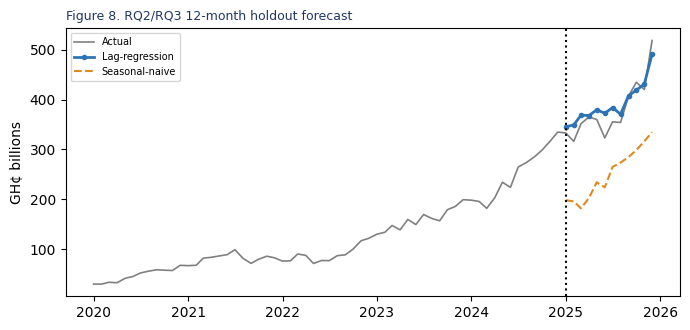

In [5]:
plt.figure(figsize=(7,3.4)); plt.plot(d.date, y/1000, color='gray', lw=1.2, label='Actual')
plt.plot(d.date.values[-H:], pred/1000, color=ACC, lw=2, marker='o', ms=3, label='Lag-regression')
plt.plot(d.date.values[-H:], d['mm_value_lag12'].values[-H:]/1000, color=ORA, ls='--', label='Seasonal-naive')
plt.axvline(d.date.values[-H], color='k', ls=':'); plt.legend(fontsize=7); plt.ylabel('GH\u00a2 billions')
plt.title('Figure 8. RQ2/RQ3 12-month holdout forecast', loc='left', color=NAVY, fontsize=9)
plt.tight_layout(); plt.savefig(FIG+'fig8_forecast.png'); plt.show()
np.save('outputs/figures/_ols_pred.npy', pred)  # reused by notebook 06